In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/house_prices.csv")


In [4]:
df

,Size,Bedrooms,Bathrooms,Price
0,80,2,1,120000
1,95,2,2,145000
2,110,3,2,175000
3,125,3,2,200000
4,140,3,3,235000
5,160,4,3,280000
6,180,4,3,330000
7,200,5,4,400000
8,220,5,4,460000
9,250,6,5,550000


In [5]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Size       10 non-null     int64
 1   Bedrooms   10 non-null     int64
 2   Bathrooms  10 non-null     int64
 3   Price      10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


,Size,Bedrooms,Bathrooms,Price
count,10.000000,10.000000,10.000000,10.00000
mean,156.000000,3.700000,2.900000,289500.00000
std,56.065438,1.337494,1.197219,143206.33909
min,80.000000,2.000000,1.000000,120000.00000
25%,113.750000,3.000000,2.000000,181250.00000
50%,150.000000,3.500000,3.000000,257500.00000
75%,195.000000,4.750000,3.750000,382500.00000
max,250.000000,6.000000,5.000000,550000.00000


In [14]:
#Create the features(inputs)
X = df[['Size', 'Bedrooms', 'Bathrooms']]
X

,Size,Bedrooms,Bathrooms
0,80,2,1
1,95,2,2
2,110,3,2
3,125,3,2
4,140,3,3
5,160,4,3
6,180,4,3
7,200,5,4
8,220,5,4
9,250,6,5


In [7]:
#The target 
y = df['Price']
y

0    120000
1    145000
2    175000
3    200000
4    235000
5    280000
6    330000
7    400000
8    460000
9    550000
Name: Price, dtype: int64

In [15]:
#check their shapes
X.shape

(10, 3)

In [13]:
y.shape

(10,)

Text(0, 0.5, 'Price')

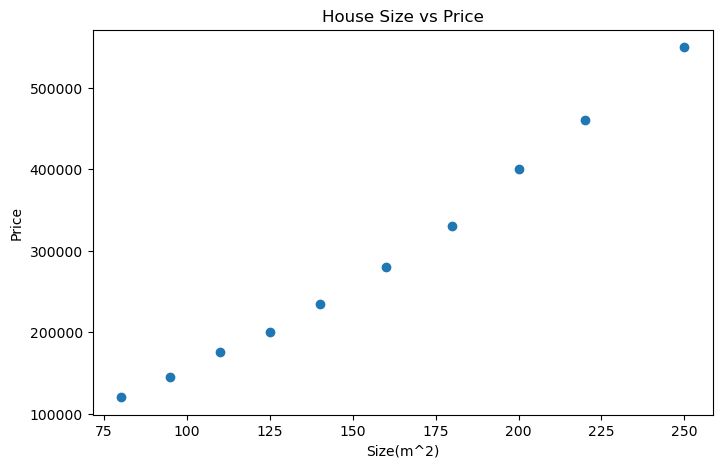

In [16]:
#Is there any relationship between house size and price
plt.figure(figsize=(8,5))
plt.scatter(df['Size'], df['Price'])
plt.title("House Size vs Price")
plt.xlabel('Size(m^2)')
plt.ylabel('Price')

In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
housing = fetch_california_housing(as_frame=True)

In [4]:
housing

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 ...       ...       ...       ...        ...         ...       ...       ...   
 20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
 20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
 20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
 20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
 20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   
 
        Longitude 

In [4]:
df = housing.frame
df.head()
df.shape
df.info()
#df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
#Understand the columns
housing.feature_names
housing.target_names

['MedHouseVal']

In [14]:
#Check for missing values
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [5]:
#Understand the target
df['MedHouseVal'].describe()

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

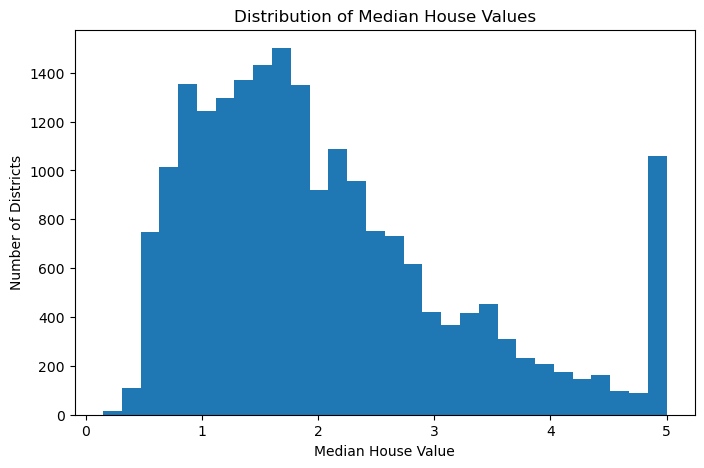

In [8]:
#The target distribution
plt.figure(figsize=(8,5))
plt.hist(df['MedHouseVal'],bins=30)
plt.title("Distribution of Median House Values")
plt.xlabel("Median House Value")
plt.ylabel("Number of Districts")

plt.savefig("../reports/target_distribution.png")
plt.show()

In [6]:
df['MedInc'].describe()

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: MedInc, dtype: float64

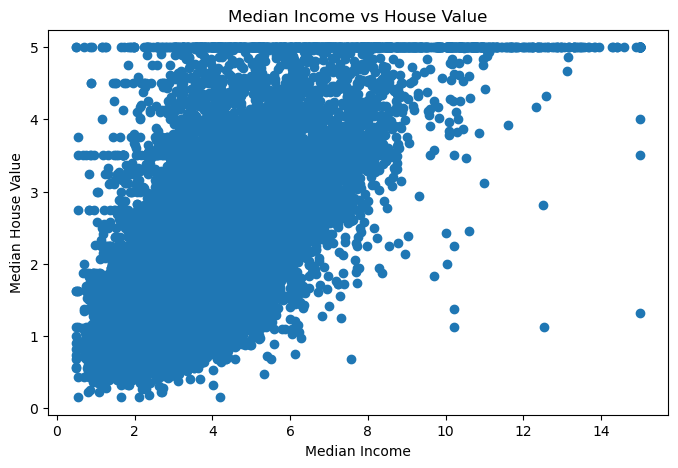

In [14]:
#Relationship between MedInc and MedHouseVal
plt.figure(figsize=(8,5))
plt.scatter(df['MedInc'],df['MedHouseVal'])
plt.title('Median Income vs House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
#plt.savefig('../reports/income_vs_house_value.png')
plt.show()

In [10]:
#Calculate the correlation
df["MedInc"].corr(df["MedHouseVal"])

np.float64(0.6880752079585475)

In [9]:
df['MedHouseVal'].corr(df['MedInc'])

np.float64(0.6880752079585474)

In [5]:
#Correlation Matrix
correlation_matrix = df.corr()
correlation_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [6]:
correlation_matrix['MedHouseVal'].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

In [5]:
#Visualize the correlation matrix
import seaborn as sns

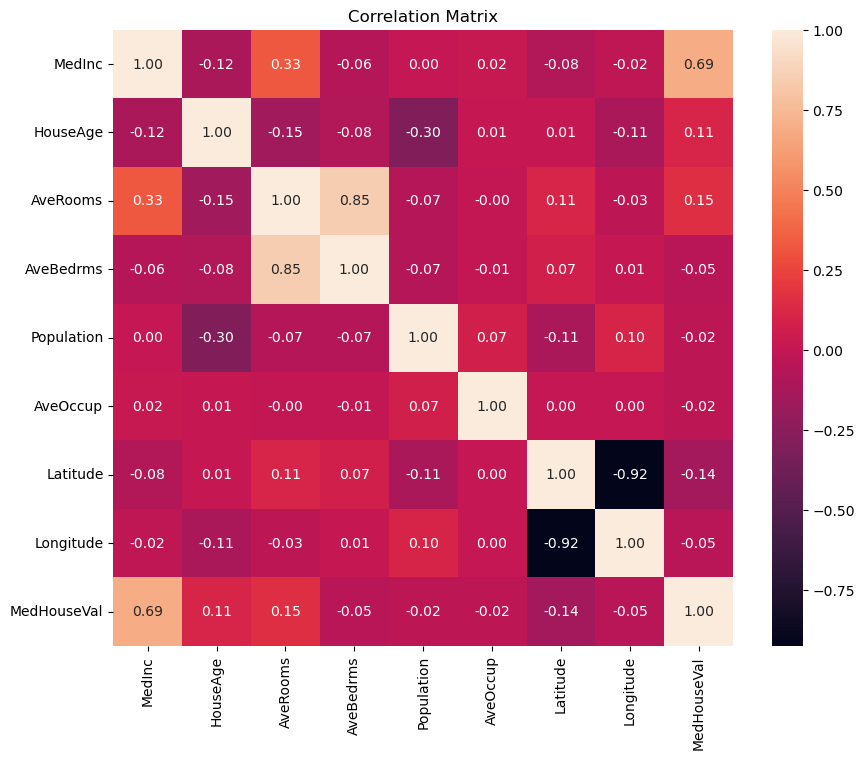

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,fmt='.2f')
plt.title("Correlation Matrix")
plt.savefig("../reports/correlation_matrix.png")
plt.show()

In [7]:
#split features and target 
X = df.drop('MedHouseVal',axis=1)
y = df['MedHouseVal']
print('X shape:',X.shape)
print('y shape:', y.shape)

X shape: (20640, 8)
y shape: (20640,)


In [7]:
print(X.loc[0])
#print(y.loc[0])

MedInc          8.325200
HouseAge       41.000000
AveRooms        6.984127
AveBedrms       1.023810
Population    322.000000
AveOccup        2.555556
Latitude       37.880000
Longitude    -122.230000
Name: 0, dtype: float64


In [8]:
#Train/Test Split
from sklearn.model_selection import train_test_split

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [9]:
#Check the shapes
print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("y_train:",y_train.shape)
print("y_test:",y_test.shape)

X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
model = LinearRegression()

In [13]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.45, 0.01,-0.12,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [14]:
#Look at what the model learned
print("Intercept:",model.intercept_)
print("Coefficients:",model.coef_)

Intercept: -37.02327770606402
Coefficients: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]


In [13]:
#Match coefficients to features
for feature,coefficient in zip(X.columns,model.coef_):
    print(feature,":",coefficient)

MedInc : 0.44867490966571755
HouseAge : 0.009724257517905264
AveRooms : -0.12332334282795908
AveBedrms : 0.7831449067929704
Population : -2.029620580140327e-06
AveOccup : -0.00352631848713413
Latitude : -0.4197924865883594
Longitude : -0.43370806496398656


In [14]:
#Make predictions 
y_pred = model.predict(X_test)

In [15]:
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251], shape=(4128,))

In [15]:
#Predict vs Actual values
comparison = pd.DataFrame({"Actual":y_test.values,"Predicted":y_pred})
comparison

,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
...,...,...
4123,2.63300,1.991746
4124,2.66800,2.249839
4125,5.00001,4.468770
4126,0.72300,1.187511


In [16]:
#Evaluation metrics
#Mean Absolute Error(MAE)
from sklearn.metrics import mean_absolute_error


In [17]:
mae = mean_absolute_error(y_test,y_pred)
print("MAE in dollars:",mae*100000,"$")

MAE in dollars: 53320.01304956566 $


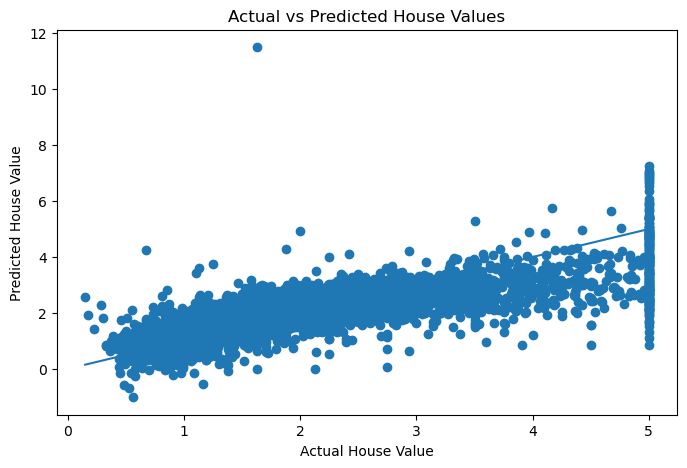

In [17]:
#Visualize Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")
plt.savefig("../reports/actual_vs_predicted.png")


In [18]:
#Evaluate the Model with R^2
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print("R^2:",r2)

R^2: 0.5757877060324511


In [19]:
#Compare training vs testing
y_train_pred = model.predict(X_train)
train_mae = mean_absolute_error(y_train,y_train_pred)
train_r2 = r2_score(y_train,y_train_pred)
print("Training MAE:", train_mae)
print("Training R^2:", train_r2)

Training MAE: 0.5286283596581935
Training R^2: 0.6125511913966952


In [20]:
#How well can we predict house value using only median income?
X_train_income = X_train[['MedInc']]
X_test_income = X_test[['MedInc']]
print(X_train_income)
print(X_test_income)

       MedInc
14196  3.2596
8267   3.8125
17445  4.1563
14265  1.9425
2271   3.5542
...       ...
11284  6.3700
11964  3.0500
5390   2.9344
860    5.7192
15795  2.5755

[16512 rows x 1 columns]
       MedInc
20046  1.6812
3024   2.5313
15663  3.4801
20484  5.7376
9814   3.7250
...       ...
15362  4.6050
16623  2.7266
18086  9.2298
2144   2.7850
3665   3.5521

[4128 rows x 1 columns]


In [21]:
income_model = LinearRegression()

In [26]:
income_model.fit(X_train_income,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.42]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['MedInc']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.4446
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [27]:
#Make predictions
y_income_pred = income_model.predict(X_test_income)
y_income_pred

array([1.14958917, 1.50606882, 1.90393718, ..., 4.31500772, 1.612455  ,
       1.93412956], shape=(4128,))

In [28]:
#Evaluate metric
income_mae = mean_absolute_error(y_test,y_income_pred)
income_r2 = r2_score(y_test,y_income_pred)
print("Income-only MAE:", income_mae)
print("Income-only R²:", income_r2)

Income-only MAE: 0.629908653009376
Income-only R²: 0.45885918903846656


In [29]:
#Put the models side by side
comparison = pd.DataFrame({"Model":["MedInc only","All 8 features"],"MAE":[income_mae,mae],
                           "R2":[income_r2,r2]})
comparison

,Model,MAE,R2
0,MedInc only,0.629909,0.458859
1,All 8 features,0.533200,0.575788


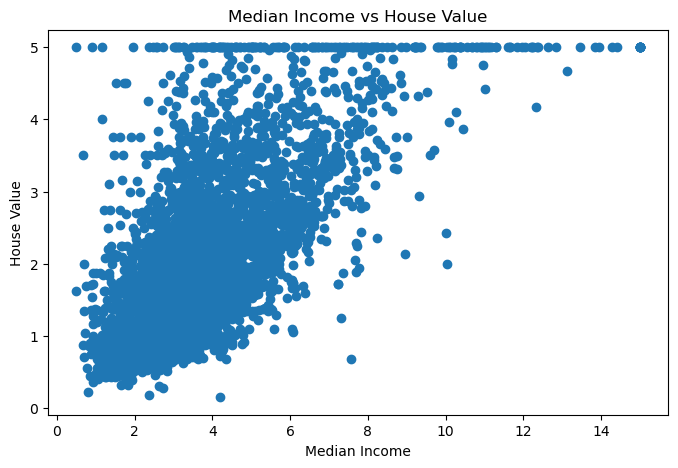

In [42]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test_income["MedInc"], y_test)

plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Median Income vs House Value")

plt.show()

In [22]:
#Better:Random Forest 
from sklearn.ensemble import RandomForestRegressor 

In [23]:
rf_model = RandomForestRegressor(n_estimators=100,random_state = 42)

In [26]:
rf_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [27]:
rf_pred =rf_model.predict(X_test)

In [28]:
rf_mae = mean_absolute_error(y_test,rf_pred)
rf_r2 = r2_score(y_test,rf_pred)
print("Random Forest MAE:", rf_mae)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 0.32773108008720936
Random Forest R²: 0.8046244867176197


In [29]:
#Compare the models
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression","Random Forest"],
    "MAE":[mae,rf_mae],
    "R2":[r2,rf_r2]})
model_comparison          

,Model,MAE,R2
0,Linear Regression,0.533200,0.575788
1,Random Forest,0.327731,0.804624


In [30]:
#Check for Overfitting
rf_train_pred = rf_model.predict(X_train)
#Evaluate the metric
rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_train_r2 = r2_score(y_train, rf_train_pred)

print("Random Forest Training MAE:", rf_train_mae)
print("Random Forest Training R²:", rf_train_r2)

Random Forest Training MAE: 0.12209520304626978
Random Forest Training R²: 0.9735148362732539


In [31]:
#Compare Training vs Test
rf_comparison = pd.DataFrame({
    "Metric": ["MAE", "R²"],
    "Training": [rf_train_mae, rf_train_r2],
    "Test": [rf_mae, rf_r2]
})

rf_comparison

,Metric,Training,Test
0,MAE,0.122095,0.327731
1,R²,0.973515,0.804624


In [32]:
#Tune Random Forest with max_depth
depths =[5,10,15,20,None]
results = []
for depth in depths:
    rf = RandomForestRegressor(
        n_estimators = 100,
        max_depth = depth,
        random_state = 42
    )
    rf.fit(X_train,y_train)
    
    predictions = rf.predict(X_test)
    
    model_mae = mean_absolute_error(y_test,predictions)
    model_r2 = r2_score(y_test,predictions)

    results.append({
        "max_depth":depth,
        "MAE": model_mae,
        "R2": model_r2
    })
depth_results = pd.DataFrame(results)
depth_results

,max_depth,MAE,R2
0,5.0,0.490488,0.646831
1,10.0,0.366316,0.773768
2,15.0,0.333124,0.800448
3,20.0,0.328070,0.804421
4,NaN,0.327731,0.804624


In [33]:
depth_results.sort_values("MAE")

,max_depth,MAE,R2
4,NaN,0.327731,0.804624
3,20.0,0.328070,0.804421
2,15.0,0.333124,0.800448
1,10.0,0.366316,0.773768
0,5.0,0.490488,0.646831


In [34]:
estimators = [10, 50, 100, 200, 300]

results = []

for n in estimators:
    rf = RandomForestRegressor(
        n_estimators=n,
        random_state=42
    )
    
    rf.fit(X_train, y_train)
    
    predictions = rf.predict(X_test)
    
    model_mae = mean_absolute_error(y_test, predictions)
    model_r2 = r2_score(y_test, predictions)
    
    results.append({
        "n_estimators": n,
        "MAE": model_mae,
        "R2": model_r2
    })
estimator_results = pd.DataFrame(results)

estimator_results

,n_estimators,MAE,R2
0,10,0.348493,0.784336
1,50,0.329797,0.804013
2,100,0.327731,0.804624
3,200,0.326793,0.805933
4,300,0.326662,0.806345


In [35]:
estimator_results.sort_values("MAE")

,n_estimators,MAE,R2
4,300,0.326662,0.806345
3,200,0.326793,0.805933
2,100,0.327731,0.804624
1,50,0.329797,0.804013
0,10,0.348493,0.784336


In [45]:
#Experiment with max_features
max_features_values =[1,2,3,4,5,6,7,8]
results = []
for max_features in max_features_values:
    rf = RandomForestRegressor(
        n_estimators = 300,
        max_features = max_features,
        random_state = 42
    )
    rf.fit(X_train,y_train)
    predictions = rf.predict(X_test)

    model_mae = mean_absolute_error(y_test,predictions)
    model_r2 = r2_score(y_test,predictions)

    results.append({
        "max_features": max_features,
        "MAE": model_mae,
        "R2": model_r2
    })
max_features_results = pd.DataFrame(results)
print(max_features_results.sort_values(by="R2",ascending=False))
print(max_features_results.sort_values(by="MAE"))

   max_features       MAE        R2
2             3  0.319261  0.817178
1             2  0.327412  0.813707
3             4  0.320988  0.813186
4             5  0.320771  0.812101
5             6  0.323845  0.809001
6             7  0.326834  0.806694
7             8  0.326662  0.806345
0             1  0.367840  0.784996
   max_features       MAE        R2
2             3  0.319261  0.817178
4             5  0.320771  0.812101
3             4  0.320988  0.813186
5             6  0.323845  0.809001
7             8  0.326662  0.806345
6             7  0.326834  0.806694
1             2  0.327412  0.813707
0             1  0.367840  0.784996


In [47]:
#Experiment with min_samples_leaf
min_samples_leaf_values = [1, 2, 4, 8, 16]
results = []
for min_samples_leaf in min_samples_leaf_values:
    rf = RandomForestRegressor(
        n_estimators = 300,
        max_features = 3,
        min_samples_leaf = min_samples_leaf,
        random_state = 42
    )
    rf.fit(X_train,y_train)
    predictions = rf.predict(X_test)
    model_mae = mean_absolute_error(y_test,predictions)
    model_r2 = r2_score(y_test,predictions)

    results.append({
        "min_samples_leaf": min_samples_leaf,
        "MAE": model_mae,
        "R2": model_r2
    })
min_samples_leaf_results = pd.DataFrame(results)
print(min_samples_leaf_results.sort_values(by="R2",ascending=False))
print(min_samples_leaf_results.sort_values(by="MAE"))

   min_samples_leaf       MAE        R2
0                 1  0.319261  0.817178
1                 2  0.320788  0.815071
2                 4  0.328398  0.807629
3                 8  0.339416  0.797823
4                16  0.358015  0.782310
   min_samples_leaf       MAE        R2
0                 1  0.319261  0.817178
1                 2  0.320788  0.815071
2                 4  0.328398  0.807629
3                 8  0.339416  0.797823
4                16  0.358015  0.782310


In [49]:
#Experiment with  min_samples_split
min_samples_split_values = [2, 5, 10, 20, 40]
results =[]
for min_samples_split in min_samples_split_values:

    rf = RandomForestRegressor(
        n_estimators=300,
        max_features=3,
        max_depth=None,
        min_samples_leaf=1,
        min_samples_split=min_samples_split,
        random_state=42
    )

    rf.fit(X_train, y_train)

    predictions = rf.predict(X_test)

    model_mae = mean_absolute_error(y_test, predictions)
    model_r2 = r2_score(y_test, predictions)

    results.append({
        "min_samples_split": min_samples_split,
        "MAE": model_mae,
        "R2": model_r2
    })
min_samples_split_results = pd.DataFrame(results)

print(min_samples_split_results.sort_values(by="R2",ascending=False))
print(min_samples_split_results.sort_values(by="MAE"))

   min_samples_split       MAE        R2
0                  2  0.319261  0.817178
1                  5  0.320469  0.816419
2                 10  0.325277  0.811776
3                 20  0.332885  0.805338
4                 40  0.348619  0.791503
   min_samples_split       MAE        R2
0                  2  0.319261  0.817178
1                  5  0.320469  0.816419
2                 10  0.325277  0.811776
3                 20  0.332885  0.805338
4                 40  0.348619  0.791503


In [50]:
#CROSS VALIDATION
from sklearn.model_selection import cross_val_score

In [51]:
cv_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    max_features=3,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)

In [53]:
cv_scores = cross_val_score(
    cv_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)
print("Cross-validation R² scores:",cv_scores)

Cross-validation R² scores: [0.82086064 0.8088846  0.82168889 0.81646751 0.8163512 ]


In [55]:
print("Mean CV R²:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Mean CV R²: 0.8168505680091407
Standard deviation: 0.00454626829615891


In [36]:
#Create the final model
final_rf_model = RandomForestRegressor(
    n_estimators = 300,
    max_depth = None,
    max_features = 3,
    min_samples_leaf = 1,
    min_samples_split=2,
    random_state =42)


In [37]:
#Train the model
final_rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [39]:
final_predictions = final_rf_model.predict(X_test)
final_mae = mean_absolute_error(y_test,final_predictions)
final_r2 = r2_score( y_test,final_predictions)
print("Final Test MAE:", final_mae)
print("Final Test R²:", final_r2)


Final Test MAE: 0.3192614953003879
Final Test R²: 0.8171784716442265


In [40]:
#Final comparison
final_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Initial Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        mae,
        rf_mae,
        final_mae
    ],
    "R2": [
        r2,
        rf_r2,
        final_r2
    ]
})

final_comparison

,Model,MAE,R2
0,Linear Regression,0.533200,0.575788
1,Initial Random Forest,0.327731,0.804624
2,Tuned Random Forest,0.319261,0.817178


In [72]:
import joblib

In [62]:
joblib.dump(final_rf_model,"../models/house_price_random_forest.pkl")

['../models/house_price_random_forest.pkl']

In [45]:
#ERROR ANALYSIS
error_analysis = pd.DataFrame({
    "Actual": y_test,
    "Predicted": final_predictions})
error_analysis["Error"] = (error_analysis["Actual"]-error_analysis["Predicted"])
error_analysis["AbsoluteError"] = (error_analysis["Error"].abs())
print(error_analysis)

        Actual  Predicted     Error  AbsoluteError
20046  0.47700   0.492933 -0.015933       0.015933
3024   0.45800   0.808410 -0.350410       0.350410
15663  5.00001   4.811110  0.188900       0.188900
20484  2.18600   2.511307 -0.325307       0.325307
9814   2.78000   2.321203  0.458797       0.458797
...        ...        ...       ...            ...
15362  2.63300   2.263130  0.369870       0.369870
16623  2.66800   1.829587  0.838413       0.838413
18086  5.00001   4.793788  0.206222       0.206222
2144   0.72300   0.729780 -0.006780       0.006780
3665   1.51500   1.702933 -0.187933       0.187933

[4128 rows x 4 columns]


In [46]:
#Look at the biggest mistakes
error_analysis.sort_values(by="AbsoluteError",ascending=False).head(10)

,Actual,Predicted,Error,AbsoluteError
6688,5.00001,1.800604,3.199406,3.199406
12389,5.00001,1.934197,3.065813,3.065813
19542,4.50000,1.437230,3.062770,3.062770
12069,5.00001,1.943537,3.056473,3.056473
10574,5.00001,2.160500,2.839510,2.839510
17306,5.00001,2.202673,2.797337,2.797337
5887,0.17500,2.923597,-2.748597,2.748597
20325,5.00001,2.402657,2.597353,2.597353
459,5.00001,2.423334,2.576676,2.576676
20349,1.25000,3.807669,-2.557669,2.557669


In [47]:
#Understand the target cap
error_analysis[
    error_analysis["Actual"] == 5.0
].sort_values(
    by="AbsoluteError",
    ascending=False
).head(10)

#Calculate MAE
print("Mean Absolute Error:",error_analysis["AbsoluteError"].mean())

Mean Absolute Error: 0.3192614953003879


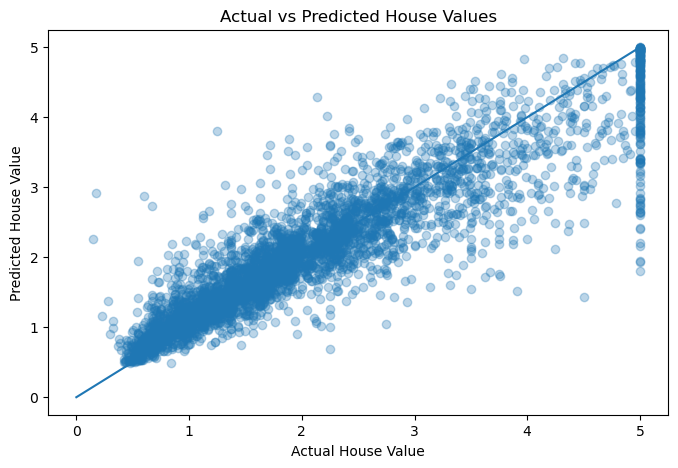

In [49]:
plt.figure(figsize=(8,5))
plt.scatter(error_analysis["Actual"],
            error_analysis["Predicted"],
            alpha = 0.3)
#Add the ideal prediction line
plt.plot(
    [0, 5],
    [0, 5]
)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")
plt.savefig("../reports/actual_vs_predicted_randomf.png")

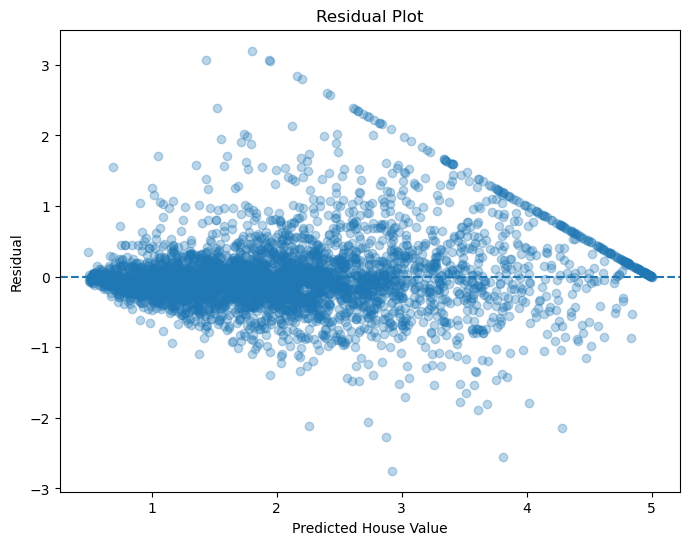

In [50]:
#Analyze the residuals
plt.figure(figsize=(8, 6))

plt.scatter(
    error_analysis["Predicted"],
    error_analysis["Error"],
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Value")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.savefig("../reports/Predicted_vs_error.png")
plt.show()

In [54]:
#Calculate errors by price range
error_analysis["ActualBin"] = pd.cut(
    error_analysis["Actual"],
    bins=[0, 1, 2, 3, 4, 5, float("inf")],
    labels=[
        "0-1",
        "1-2",
        "2-3",
        "3-4",
        "4-5",
        "5+"
    ],
    include_lowest=True
)
print(error_analysis.groupby("ActualBin")["AbsoluteError"].mean())
print(error_analysis["ActualBin"].value_counts().sort_index())
print(error_analysis.groupby("ActualBin")["Error"].mean())

ActualBin
0-1    0.235615
1-2    0.233123
2-3    0.313184
3-4    0.486926
4-5    0.710913
5+     0.770481
Name: AbsoluteError, dtype: float64
ActualBin
0-1     739
1-2    1682
2-3     956
3-4     412
4-5     160
5+      179
Name: count, dtype: int64
ActualBin
0-1   -0.215825
1-2   -0.140073
2-3    0.006848
3-4    0.260660
4-5    0.661840
5+     0.770481
Name: Error, dtype: float64


In [55]:
#Use  RMSE
from sklearn.metrics import mean_squared_error

In [59]:
rmse = mean_squared_error(
    y_test,
    final_predictions
) ** 0.5

print("RMSE:", rmse)
print("RMSE in dollars:", rmse * 100000)

RMSE: 0.48945987800138313
RMSE in dollars: 48945.98780013831


In [60]:
#RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
#parameter distributions
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 10, 15, 20, 25],
    "max_features": [2, 3, 4, 5, 6],
    "min_samples_leaf": [1, 2, 4],
    "min_samples_split": [2, 5, 10]
}

In [61]:
#base random forest
rf = RandomForestRegressor(random_state=42)
#Create the search
random_search = RandomizedSearchCV(
    estimator = rf,
    param_distributions = param_dist,
    n_iter = 20,
    cv = 5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)
#Run the search
random_search.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for mul

In [67]:
print("Best parameters:",random_search.best_params_)
#best cross-validation score
print("Best CV R^2:",random_search.best_score_)
best_rf_model = random_search.best_estimator_
print(best_rf_model)

Best parameters: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 3, 'max_depth': None}
Best CV R^2: 0.817854025504183
Best parameters: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 3, 'max_depth': None}
RandomForestRegressor(max_features=3, n_estimators=400, random_state=42)


In [63]:
#Evaluate it on the test set
search_predictions = best_rf_model.predict(X_test)

In [65]:
search_mae = mean_absolute_error(y_test,search_predictions)
search_r2 = r2_score(y_test,search_predictions)
print("Test MAE:",search_mae)
print("Test R^2:",search_r2)

Test MAE: 0.31871482059714185
Test R^2: 0.8178107745610371


In [66]:
#Compare with our current model
comparison = pd.DataFrame({
    "Model":[
        "Manual Tuned Random Forest",
        "RandomizedSearchCV Random Forest"
    ],
    "MAE":[
        final_mae,
        search_mae
    ],
    "R2":[
        final_r2,
        search_r2
    ]
})
print(comparison)            

                              Model       MAE        R2
0        Manual Tuned Random Forest  0.319261  0.817178
1  RandomizedSearchCV Random Forest  0.318715  0.817811


In [68]:
#Choosing the final random forest configuration
final_rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    max_features=3,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
    n_jobs = -1   
)
#Train the final model
final_rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",3
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max

In [69]:
#Make final test predictions
final_predictions = final_rf_model.predict(X_test)
#Calculate the final MAE
final_mae = mean_absolute_error(y_test,final_predictions)
final_r2 = r2_score(y_test,final_predictions)
print("Final Test MAE:", final_mae)
print("Final Test R²:", final_r2)

Final Test MAE: 0.31871482059714185
Final Test R²: 0.8178107745610371


In [70]:
#Clean final report
print("Final Random Forest Model")
print("-------------------------")
print("n_estimators:", final_rf_model.n_estimators)
print("max_depth:", final_rf_model.max_depth)
print("max_features:", final_rf_model.max_features)
print("min_samples_leaf:", final_rf_model.min_samples_leaf)
print("min_samples_split:", final_rf_model.min_samples_split)
print()
print("Test MAE:", final_mae)
print("Test R²:", final_r2)

Final Random Forest Model
-------------------------
n_estimators: 400
max_depth: None
max_features: 3
min_samples_leaf: 1
min_samples_split: 2

Test MAE: 0.31871482059714185
Test R²: 0.8178107745610371


In [73]:
#Save the model
joblib.dump(final_rf_model,"../models/house_price_random_forest.pkl")

['../models/house_price_random_forest.pkl']

In [74]:
#Test that we can load the model
loaded_model = joblib.load("../models/house_price_random_forest.pkl")

In [76]:
loaded_predictions = loaded_model.predict(X_test)
#Compare the predictions
print(
    "Predictions identical:",
    (final_predictions == loaded_predictions).all()
)

Predictions identical: False


In [80]:
#Check the actual difference
print("Maximum prediction difference:",
      np.max(np.abs(final_predictions-loaded_predictions)))
print(
    "Predictions approximately identical:",
    np.allclose(final_predictions, loaded_predictions)
)

Maximum prediction difference: 1.3322676295501878e-15
Predictions approximately identical: True
